#  Calculation of features from available libraries

In [1]:
import sys
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')

import os
import pandas as pd

dataset = 'Fe-Mo'
system=dataset.replace('-','')
from BopFoxFeaturizer.Featurizer import Featurizer

BS = pd.read_pickle(os.path.join(dataset, 'FullyCuratedParsedBriefSummary.pkl'))
AtomsObjects = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{system}-sorted-POSCAR-initial-rescaled-PymatgenStructures.pkl')).dropna()
BS.dropna(inplace=True)

## Prepare Extra features

In [2]:
Features = Featurizer(BS)

In [3]:
DatasetCompositionFeatures = Features.get_fractions_by_components()

In [4]:
DatasetMagneticFeature = Features.Mag
#DatasetMagneticFeature = DatasetMagneticFeature.str.replace('FM','1.')
#DatasetMagneticFeature = DatasetMagneticFeature.str.replace('NM','0.').astype(float)
DatasetMagneticFeature.name = 'Mag'

In [5]:
StructureNameFeature = BS.Phase

In [6]:
StructureNameFeature.name='Structure'

In [7]:
DatasetFeatures = pd.concat((DatasetCompositionFeatures, DatasetMagneticFeature, StructureNameFeature), axis=1)

In [8]:
from sklearn.preprocessing import  OneHotEncoder

In [9]:
encoder = OneHotEncoder()

In [10]:
encoder.fit(DatasetFeatures[['Structure', 'Mag']])

OneHotEncoder()

In [11]:
transformed = encoder.transform(DatasetFeatures[['Structure', 'Mag']])

In [12]:
dftransformed = pd.DataFrame(transformed.toarray(), columns = encoder.get_feature_names_out(), index = DatasetFeatures.index)

In [13]:
DatasetFeatures.drop(columns = ['Mag', 'Structure'],  inplace=True)

In [14]:
DatasetFeatures = pd.concat([DatasetFeatures, dftransformed], axis = 1)

In [15]:
datasetfeatureslocation = os.path.join(dataset, 'Descriptors','DatasetFeatures.pkl')

# Matminer Features 

In [16]:
from Tools.DatasetTools.GetPymatgenFeatures import *

In [17]:
descriptorslocation = os.path.join(dataset, 'Descriptors')
mmflatomic = os.path.join(descriptorslocation, 'matminer_atomic_features.pkl')
mmfdensity = os.path.join (descriptorslocation, 'matminer_density_features.pkl')
mmfcomposition =  os.path.join (descriptorslocation,'matminer_composition_features.pkl')
mmfstructure =  os.path.join (descriptorslocation,'matminer_structure_features.pkl')
mmsoapfeatures = os.path.join(descriptorslocation, 'matminer_soap_features.pkl')


BS['chemical_formula'] = get_chemical_formula(BS)

In [18]:
BS['composition'] = StrToComposition().featurize_dataframe(BS, "chemical_formula")['composition']

StrToComposition:   0%|          | 0/289 [00:00<?, ?it/s]

In [19]:
BS['atoms_objects'] = AtomsObjects

In [20]:
AtomicFeaturesMagpie = load_features(mmflatomic, BS, which='atomic')
DensitiFeatures= load_features(mmfdensity, BS, which='density')
CompositionFeatures = load_features(mmfcomposition, BS, which='composition')
# SOAPFeatures = load_features(mmfstructure, BS, which='soap')
# SOAP doesnt work from matminer
# StructureFeatures = load_features(mmfstructure, BS, which='structure')

In [21]:
AtomicFeaturesMagpie.columns = AtomicFeaturesMagpie.columns.str.replace('MagpieData ','')
AtomicFeaturesMagpie.dropna(axis=1, inplace = True)
AtomicFeaturesMagpie.describe()

,minimum Number,maximum Number,range Number,mean Number,avg_dev Number,mode Number,minimum MendeleevNumber,maximum MendeleevNumber,range MendeleevNumber,mean MendeleevNumber,...,range GSmagmom,mean GSmagmom,avg_dev GSmagmom,mode GSmagmom,minimum SpaceGroupNumber,maximum SpaceGroupNumber,range SpaceGroupNumber,mean SpaceGroupNumber,avg_dev SpaceGroupNumber,mode SpaceGroupNumber
count,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,...,289.000000,289.000000,289.000000,289.000000,289.0,289.0,289.0,289.0,289.0,289.0
mean,27.217993,40.948097,13.730104,39.126264,2.732522,40.615917,50.328720,54.619377,4.290657,50.898042,...,1.811226,0.379093,0.360465,0.182583,229.0,229.0,0.0,229.0,0.0,229.0
std,4.250517,3.972222,5.592327,3.989525,2.268611,4.505539,1.241319,1.328287,1.747602,1.246727,...,0.737720,0.526284,0.299267,0.594355,0.0,0.0,0.0,0.0,0.0,0.0
min,26.000000,26.000000,0.000000,26.000000,0.000000,26.000000,50.000000,50.000000,0.000000,50.000000,...,0.000000,0.000000,0.000000,0.000000,229.0,229.0,0.0,229.0,0.0,229.0
25%,26.000000,42.000000,16.000000,39.061224,0.904892,42.000000,50.000000,55.000000,5.000000,50.212766,...,2.110663,0.089815,0.119370,0.000000,229.0,229.0,0.0,229.0,0.0,229.0
50%,26.000000,42.000000,16.000000,40.545455,2.223930,42.000000,50.000000,55.000000,5.000000,50.454545,...,2.110663,0.191878,0.293373,0.000000,229.0,229.0,0.0,229.0,0.0,229.0
75%,26.000000,42.000000,16.000000,41.319149,4.444444,42.000000,50.000000,55.000000,5.000000,50.918367,...,2.110663,0.387673,0.586295,0.000000,229.0,229.0,0.0,229.0,0.0,229.0
max,42.000000,42.000000,16.000000,42.000000,7.933884,42.000000,55.000000,55.000000,5.000000,55.000000,...,2.110663,2.110663,1.046610,2.110663,229.0,229.0,0.0,229.0,0.0,229.0


In [22]:
DensitiFeatures.dropna(axis=1, inplace=True)
if DensitiFeatures.shape[1] > 0:
    DensitiFeatures.describe()

In [23]:
CompositionFeatures.dropna(axis=1, inplace=True)
CompositionFeatures.describe()

,HOMO_energy,LUMO_energy,gap_AO,band center,max ionic char,avg ionic char,0-norm,2-norm,3-norm,5-norm,7-norm,10-norm
count,289.000000,289.000000,289.0,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000
mean,-0.162972,-0.162972,0.0,3.939285,0.023047,0.002293,1.858131,0.907015,0.896017,0.892222,0.891545,0.891299
std,0.035292,0.035292,0.0,0.028412,0.009387,0.001904,0.349520,0.081019,0.097394,0.105097,0.106785,0.107461
min,-0.295049,-0.295049,0.0,3.918947,0.000000,0.000000,1.000000,0.710023,0.635124,0.583580,0.564976,0.553682
25%,-0.153347,-0.153347,0.0,3.923732,0.026858,0.000759,2.000000,0.849837,0.835550,0.833387,0.833335,0.833333
50%,-0.153347,-0.153347,0.0,3.929177,0.026858,0.001867,2.000000,0.927903,0.925021,0.924856,0.924855,0.924855
75%,-0.153347,-0.153347,0.0,3.939644,0.026858,0.003730,2.000000,0.971311,0.970883,0.970874,0.970874,0.970874
max,-0.153347,-0.153347,0.0,4.032960,0.026858,0.006659,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Pyscal features 

In [24]:
atomsobjectlocation = os.path.join(dataset, 'Atomsobjects')
atomsobjectfile = os.path.join(atomsobjectlocation,f'{system}-sorted-POSCAR-initial-rescaled-AtomsObjects.pkl')

In [25]:
from tqdm.auto import tqdm
from Tools.DatasetTools import pyscalfeaturizers as pf
from BopFoxFeaturizer.struct_db import struct_db
AtomsObjects = pd.read_pickle(atomsobjectfile).dropna()

In [26]:
featurizers = [pf.pyscal_steinhardt, pf.pyscal_cn] #, get_steinhardt]
pyscal_features = [feature.__name__ for feature in featurizers]

pyscalsteinhardt = os.path.join(descriptorslocation, 'pyscal_steinhardt.kpl')

if os.path.exists(pyscalsteinhardt):
    PyscalFeatures = pd.read_pickle(pyscalsteinhardt)
else:
    PyscalFeatures = pf.featurize_many(AtomsObjects,  featurizers, colid='atoms')
    expanded_ste = pf.expand_features(PyscalFeatures.pyscal_steinhardt, 'pyscal_steinhardt')
    PyscalFeatures = pd.concat([expanded_ste, PyscalFeatures.pyscal_cn], axis=1)
    PyscalFeatures.to_pickle(pyscalsteinhardt)

In [27]:
PyscalFeatures

,pyscal_steinhardt_0,pyscal_steinhardt_1,pyscal_cn
Fe_pv8Mo_sv22.sigma-BBABB.FM,"[0.09617556302880141, 0.09617556302880138, 0.0...","[0.645723632201294, 0.645723632201294, 0.31584...","[12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 1..."
Fe_pv10Mo_sv20.sigma-ABBAB.FM,"[0.09617556302880119, 0.09617556302880147, 0.0...","[0.6457236322012941, 0.6457236322012939, 0.315...","[12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 1..."
Fe_pv4Mo_sv20.C36-ABBBB.FM,"[0.011022436115045555, 0.011022436115045475, 0...","[0.1919795859504777, 0.1919795859504777, 0.191...","[16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 1..."
Fe_pv3Mo_sv10.mu-ABBBA.FM,"[0.08910515349838412, 0.06417559966989628, 0.0...","[0.6472706104443743, 0.6305396060781814, 0.630...","[12, 12, 12, 12, 12, 12, 12, 15, 15, 16, 16, 1..."
Fe_pv5Mo_sv24.chi-AABB.FM,"[0.03160847926125851, 0.029443310707755407, 0....","[0.19382539926827577, 0.19699867479152294, 0.1...","[16, 16, 16, 16, 16, 13, 13, 13, 13, 13, 13, 1..."
...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,"[0.08910515349838412, 0.06417559966989628, 0.0...","[0.6472706104443743, 0.6305396060781814, 0.630...","[12, 12, 12, 12, 12, 12, 12, 15, 15, 16, 16, 1..."
Fe_pv8Mo_sv22.sigma-BBABB.NM,"[0.09617556302880141, 0.09617556302880138, 0.0...","[0.645723632201294, 0.645723632201294, 0.31584...","[12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 1..."
Fe_pv1Mo_sv3.L12-AB3.FM,"[0.19094065395649326, 0.19094065395649326, 0.1...","[0.5745242597140696, 0.5745242597140696, 0.574...","[12, 12, 12, 12]"
Fe_pv8Mo_sv22.sigma-BBBBA.FM,"[0.09617556302880141, 0.09617556302880138, 0.0...","[0.645723632201294, 0.645723632201294, 0.31584...","[12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 1..."


# Dataset features from CN 

The first feature that we would like to have is the count of each CP in each sample. for that we construct a vector in the following way:

$$ N_{CN}^i = \#^i CN $$

## amount of sites in structure

In [28]:
import Tools.DatasetTools.GeneralFeaturizer as gf

In [29]:
from importlib.machinery import SourceFileLoader
gf = SourceFileLoader('gf','Tools/DatasetTools/GeneralFeaturizer.py').load_module()

In [30]:
CN = gf.featurize_series(PyscalFeatures['pyscal_cn'], PyscalFeatures.pyscal_cn, normalization='NCP', return0 = False)
newcolumns = ['N'+col for col in CN.columns]
CN.columns = newcolumns

In [31]:
CN

,N_CN12,N_CN13,N_CN14,N_CN15,N_CN16
Fe_pv8Mo_sv22.sigma-BBABB.FM,10.0,0.0,16.0,4.0,0.0
Fe_pv10Mo_sv20.sigma-ABBAB.FM,10.0,0.0,16.0,4.0,0.0
Fe_pv4Mo_sv20.C36-ABBBB.FM,16.0,0.0,0.0,0.0,8.0
Fe_pv3Mo_sv10.mu-ABBBA.FM,7.0,0.0,2.0,2.0,2.0
Fe_pv5Mo_sv24.chi-AABB.FM,0.0,12.0,0.0,0.0,5.0
...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,7.0,0.0,2.0,2.0,2.0
Fe_pv8Mo_sv22.sigma-BBABB.NM,10.0,0.0,16.0,4.0,0.0
Fe_pv1Mo_sv3.L12-AB3.FM,4.0,0.0,0.0,0.0,0.0
Fe_pv8Mo_sv22.sigma-BBBBA.FM,10.0,0.0,16.0,4.0,0.0


## Composition on CP

Next feature we want is the composition in each CP. for this we choose to represent the elment numerically by their atomic numbers, and the CP-resolved composition becomes the average atomc numbers,

$$ Z_{CP} ^i = \dfrac{1}{n_{at}^i} \sum_{at \in CP} Z_{at} $$

In [32]:
from mendeleev import element

In [33]:
AtomicNumbers=AtomsObjects.atoms.map(lambda a: a.numbers)
AtomicNumbers.name = 'AtomicNumbers'

In [34]:
symbols = dataset.split('-')

In [35]:
volums = {symb: element(symb).atomic_volume for symb in symbols}

In [36]:
AtomicVolumes = AtomsObjects.atoms.map(lambda a: [volums[at] for at in a.get_chemical_symbols()])

In [37]:
CPVol = gf.featurize_series(AtomicVolumes, PyscalFeatures.pyscal_cn, return0=False)
newcolumns = ['V'+col for col in CPVol.columns]
CPVol.columns =  newcolumns

In [38]:
CPComp = gf.featurize_series(AtomicNumbers, PyscalFeatures.pyscal_cn, return0=False)
newcolumns = ['Z'+col for col in CPComp.columns]
CPComp.columns = newcolumns

In [39]:
DatasetFeatures = pd.concat([DatasetFeatures, CN, CPComp,CPVol], axis=1)

In [40]:
DatasetFeatures.to_pickle(datasetfeatureslocation)

In [41]:
DatasetFeatures

,Fe_pv,Mo_sv,Structure_A15,Structure_C14,Structure_C15,Structure_C36,Structure_R,Structure_bcc,Structure_chi,Structure_delta,...,Z_CN12,Z_CN13,Z_CN14,Z_CN15,Z_CN16,V_CN12,V_CN13,V_CN14,V_CN15,V_CN16
Fe_pv8Mo_sv22.sigma-BBABB.FM,0.266667,0.733333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12.933333,0.00000,21.333333,3.466667,0.000000,2.980000,0.000000,4.860000,0.946667,0.000000
Fe_pv10Mo_sv20.sigma-ABBAB.FM,0.333333,0.666667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12.933333,0.00000,20.266667,3.466667,0.000000,2.980000,0.000000,4.706667,0.946667,0.000000
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.166667,0.833333,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,28.000000,0.00000,0.000000,0.000000,11.333333,6.266667,0.000000,0.000000,0.000000,2.750000
Fe_pv3Mo_sv10.mu-ABBBA.FM,0.230769,0.769231,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.923077,0.00000,6.461538,6.461538,6.461538,4.530769,0.000000,1.446154,1.446154,1.446154
Fe_pv5Mo_sv24.chi-AABB.FM,0.172414,0.827586,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.000000,17.37931,0.000000,0.000000,4.482759,0.000000,3.889655,0.000000,0.000000,1.224138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,0.230769,0.769231,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.923077,0.00000,6.461538,6.461538,6.461538,4.530769,0.000000,1.446154,1.446154,1.446154
Fe_pv8Mo_sv22.sigma-BBABB.NM,0.266667,0.733333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12.933333,0.00000,21.333333,3.466667,0.000000,2.980000,0.000000,4.860000,0.946667,0.000000
Fe_pv1Mo_sv3.L12-AB3.FM,0.250000,0.750000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,38.000000,0.00000,0.000000,0.000000,0.000000,8.825000,0.000000,0.000000,0.000000,0.000000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,0.266667,0.733333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12.933333,0.00000,21.333333,3.466667,0.000000,2.980000,0.000000,4.860000,0.946667,0.000000


## Stainhardt parameters 

From the Steinhardt parameters obtained by Pyscal library, we also want to average over the coordination polyhedra. This time we are also saving the total average for each parameter.

$$ q_{j, CP} ^i = \dfrac{1}{n_{at}^i}\sum _{at \in CP} q_{j, at} ^i $$

In [42]:
thisFeatures = PyscalFeatures[['pyscal_steinhardt_0','pyscal_steinhardt_1']]

In [43]:
CNPyscal  = gf.featurize_many(thisFeatures, PyscalFeatures.pyscal_cn, [gf.cn_average])

  0%|          | 0/1 [00:00<?, ?it/s]

In [44]:
CNPyscal

,pyscal_steinhardt_0_0,pyscal_steinhardt_0_CN12,pyscal_steinhardt_0_CN13,pyscal_steinhardt_0_CN14,pyscal_steinhardt_0_CN15,pyscal_steinhardt_0_CN16,pyscal_steinhardt_1_0,pyscal_steinhardt_1_CN12,pyscal_steinhardt_1_CN13,pyscal_steinhardt_1_CN14,pyscal_steinhardt_1_CN15,pyscal_steinhardt_1_CN16
Fe_pv8Mo_sv22.sigma-BBABB.FM,0.063293,0.037974,0.000000,0.022234,0.003085,0.000000,0.469031,0.209215,0.000000,0.217703,0.042113,0.000000
Fe_pv10Mo_sv20.sigma-ABBAB.FM,0.063293,0.037974,0.000000,0.022234,0.003085,0.000000,0.469031,0.209215,0.000000,0.217703,0.042113,0.000000
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.028944,0.026217,0.000000,0.000000,0.000000,0.002727,0.502143,0.437765,0.000000,0.000000,0.000000,0.064378
Fe_pv3Mo_sv10.mu-ABBBA.FM,0.043541,0.036474,0.000000,0.004550,0.000248,0.002268,0.478648,0.340808,0.000000,0.061350,0.045118,0.031371
Fe_pv5Mo_sv24.chi-AABB.FM,0.081875,0.000000,0.030092,0.000000,0.000000,0.005151,0.471315,0.000000,0.186997,0.000000,0.000000,0.033856
...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,0.043541,0.036474,0.000000,0.004550,0.000248,0.002268,0.478648,0.340808,0.000000,0.061350,0.045118,0.031371
Fe_pv8Mo_sv22.sigma-BBABB.NM,0.063293,0.037974,0.000000,0.022234,0.003085,0.000000,0.469031,0.209215,0.000000,0.217703,0.042113,0.000000
Fe_pv1Mo_sv3.L12-AB3.FM,0.190941,0.190941,0.000000,0.000000,0.000000,0.000000,0.574524,0.574524,0.000000,0.000000,0.000000,0.000000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,0.063293,0.037974,0.000000,0.022234,0.003085,0.000000,0.469031,0.209215,0.000000,0.217703,0.042113,0.000000


In [45]:
PyscalFeaturesFile = os.path.join(descriptorslocation,'CNAVPyscal.pkl')

In [46]:
CNPyscal.to_pickle(PyscalFeaturesFile)

# Characterization of Dataset Features 

In [47]:
import matplotlib.pyplot as plt

In [48]:
import seaborn as sns

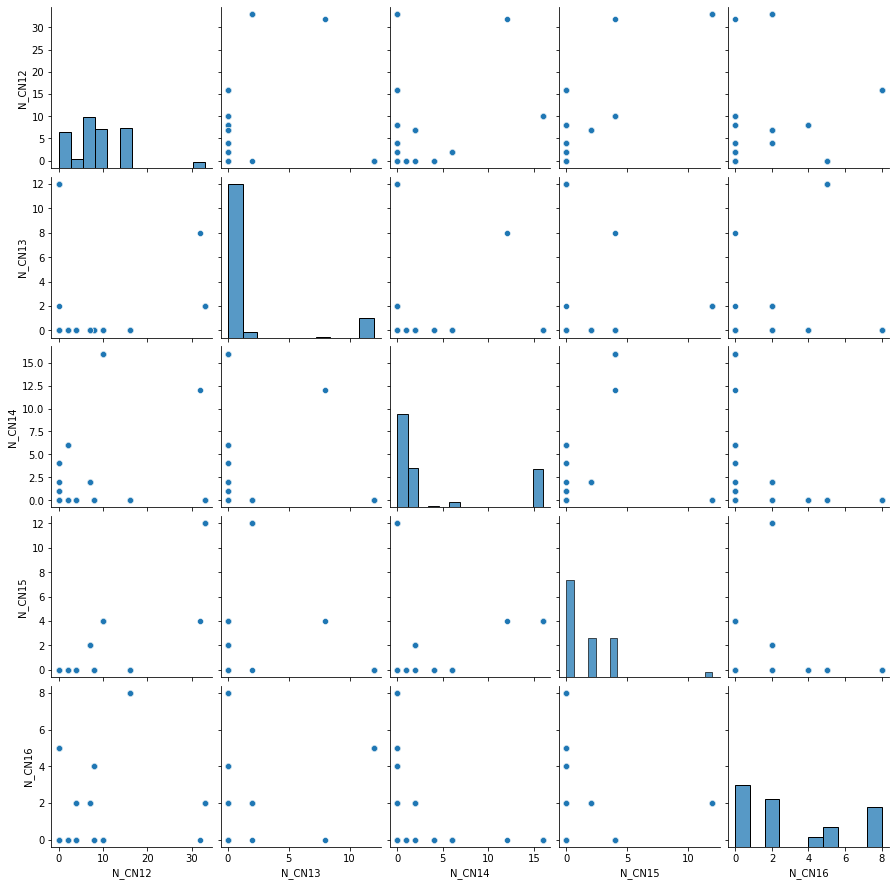

In [49]:
sns.pairplot(CN)

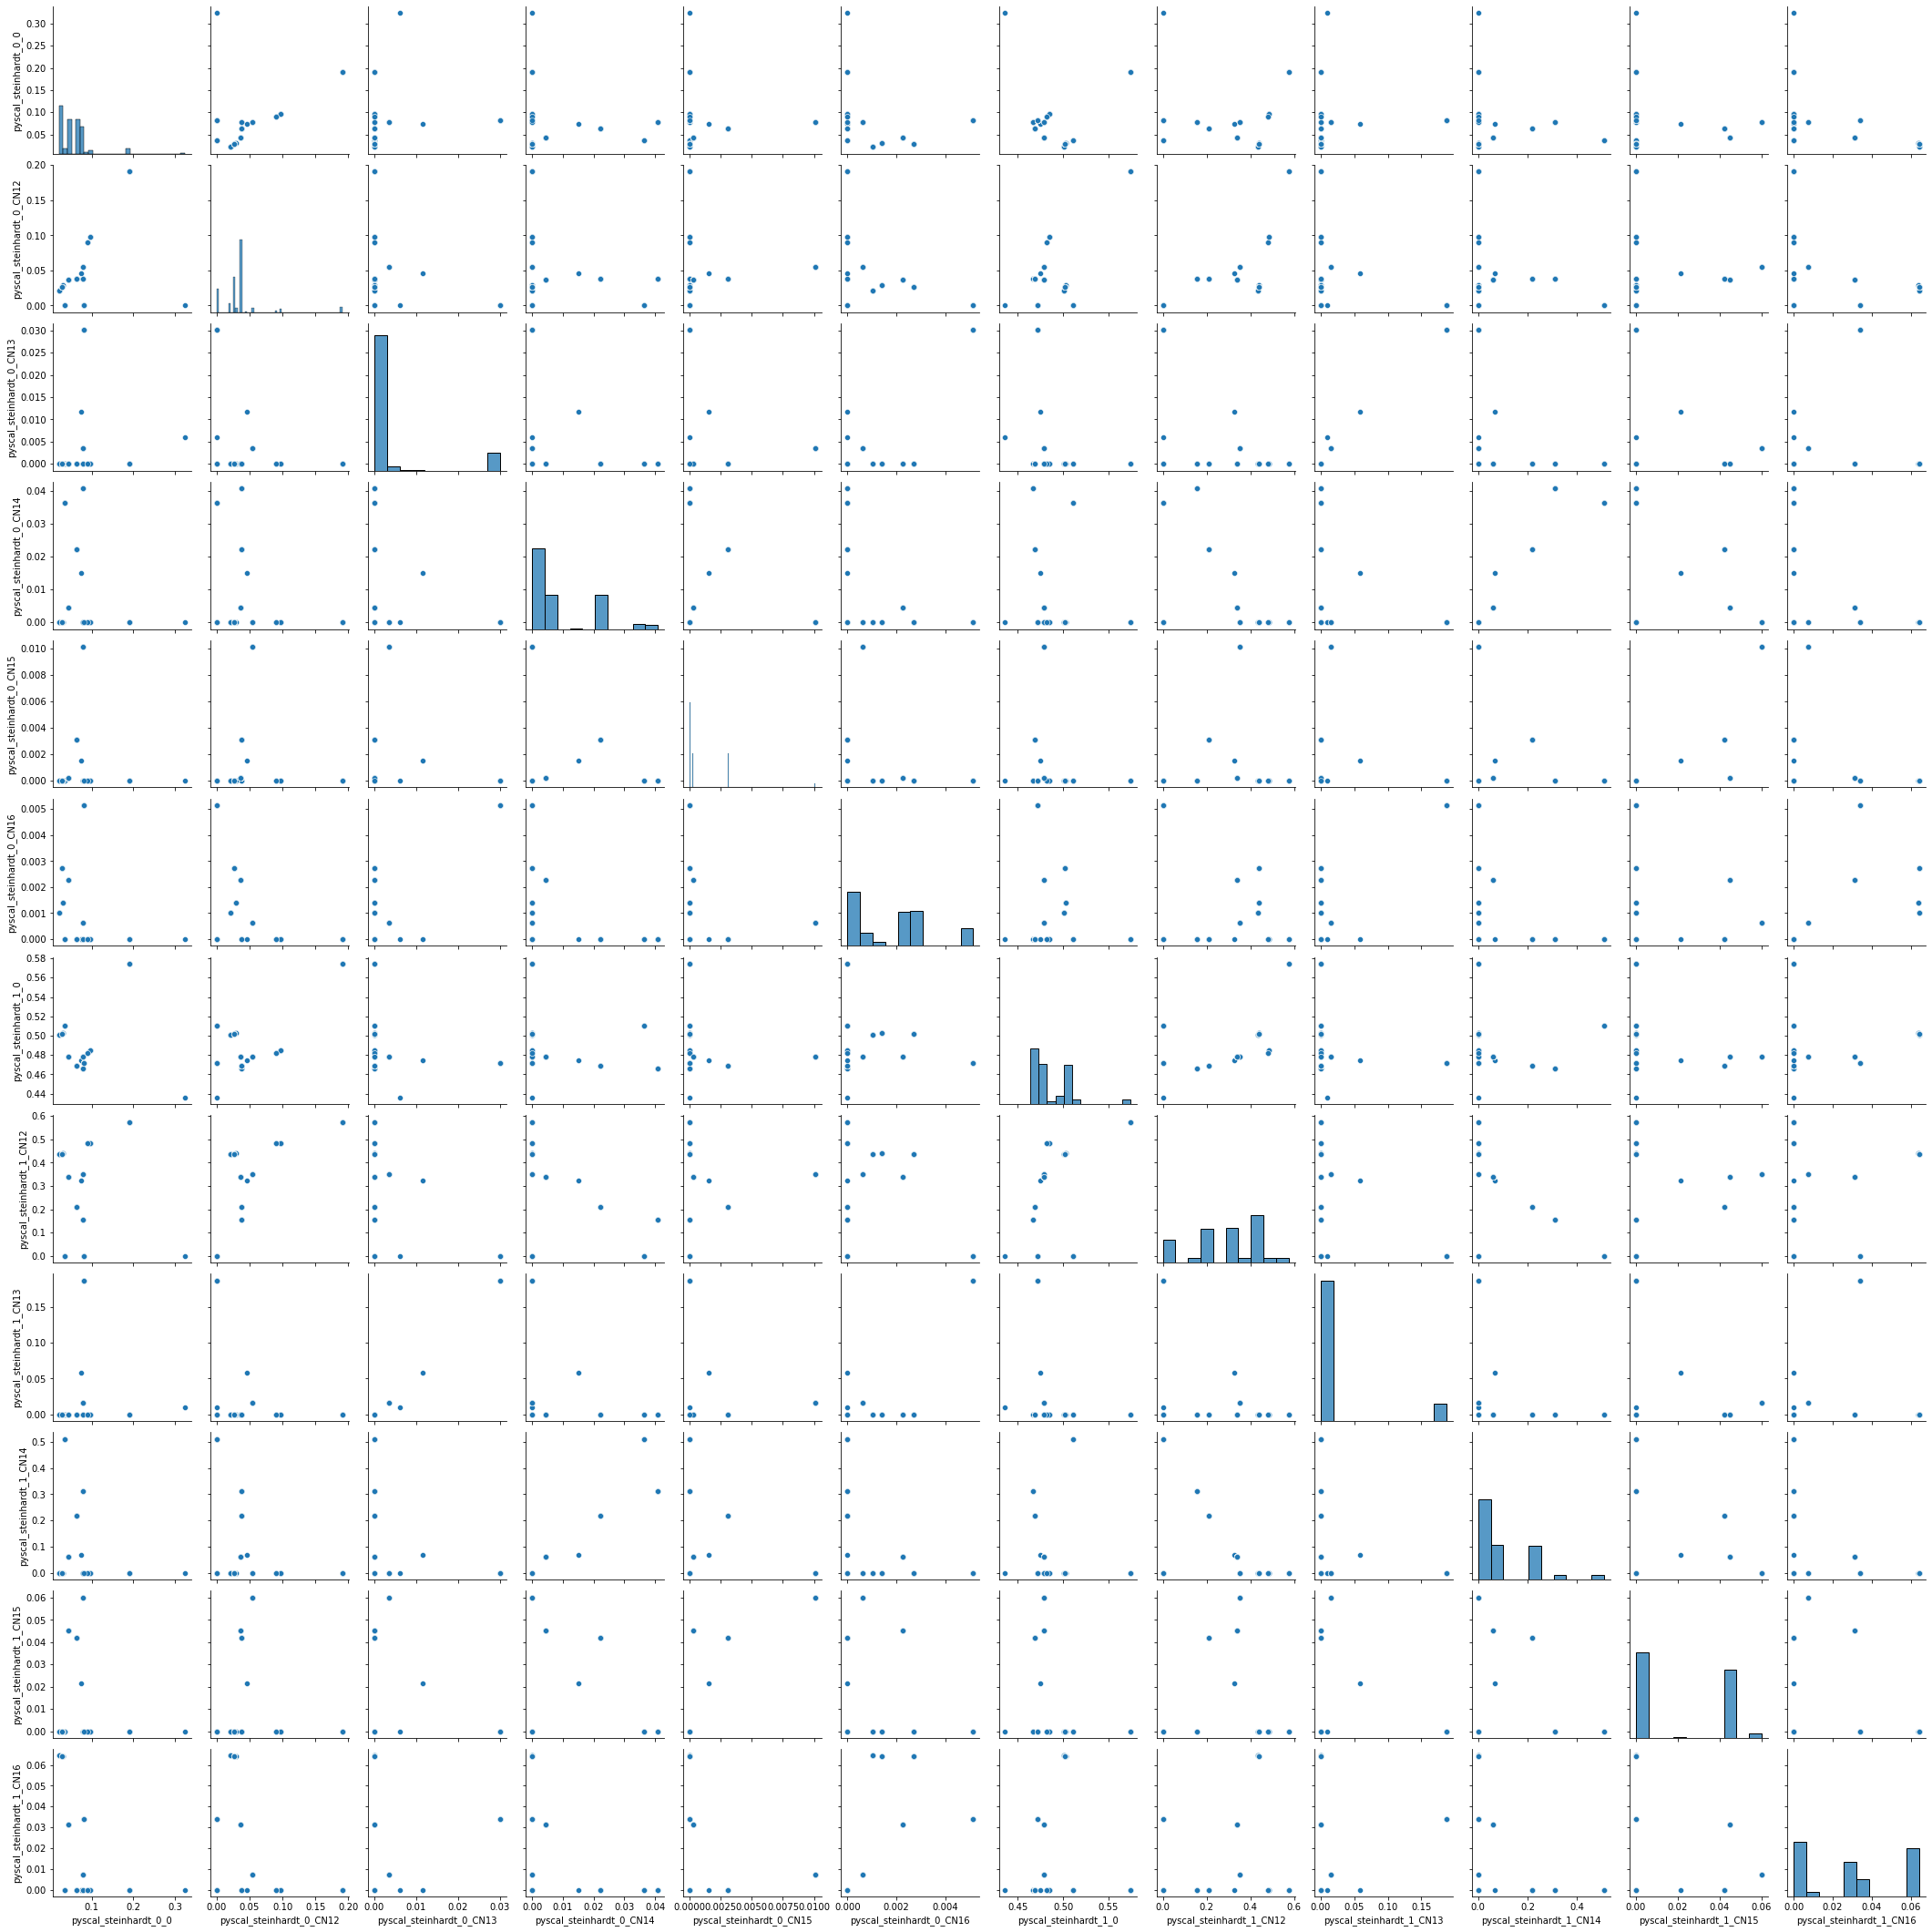

In [50]:
sns.pairplot(CNPyscal)

# compare to alesya's descriptors

In [51]:
previous = pd.read_csv('Fe-Mo/DATAforML_without_BOP.csv')

In [52]:
previous = previous.set_index('index1')

In [53]:
previous

,Name,V,E0,nelem,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,EF,...,Pos_8,Pos_9,Pos_10,Pos_11,fr_Fe_specif,Z12,Z13,Z14,Z15,Z16
index1,,,,,,,,,,,,,,,,,,,,,
Fe_pv8Mo_sv22.sigma-BBABB.FM,bulk sigma-BBABB.FM,14.954763,-10.004507,2,Fe_pv,Mo_sv,8,22,30.0,0.215379,...,0,0,0,0,0.266667,9.380000,0.00,8.235,9.38,0.000
Fe_pv10Mo_sv20.sigma-ABBAB.FM,bulk sigma-ABBAB.FM,14.130625,-10.006896,2,Fe_pv,Mo_sv,10,20,30.0,0.034391,...,0,0,0,0,0.333333,7.090000,0.00,9.380,9.38,0.000
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923,-10.007837,2,Fe_pv,Mo_sv,4,20,24.0,0.479948,...,0,0,0,0,0.166667,9.380000,0.00,0.000,0.00,8.235
Fe_pv3Mo_sv10.mu-ABBBA.FM,bulk mu-ABBBA.FM,15.378254,-10.008565,2,Fe_pv,Mo_sv,3,10,13.0,0.307490,...,0,0,0,0,0.230769,9.052857,0.00,7.090,9.38,9.380
Fe_pv5Mo_sv24.chi-AABB.FM,bulk chi-AABB.FM,15.751001,-10.015010,2,Fe_pv,Mo_sv,5,24,29.0,0.457378,...,0,0,0,0,0.172414,9.380000,9.38,0.000,0.00,7.090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv18.C36-BBBAB.FM,bulk C36-BBBAB.FM,14.876555,-9.972888,2,Fe_pv,Mo_sv,6,18,24.0,0.291648,...,0,0,0,0,0.250000,8.521250,0.00,0.000,0.00,9.380
Fe_pv3Mo_sv10.mu-ABBBA.NM,bulk mu-ABBBA,15.125643,-9.973264,2,Fe_pv,Mo_sv,3,10,13.0,0.342791,...,0,0,0,0,0.230769,9.052857,0.00,7.090,9.38,9.380
Fe_pv8Mo_sv22.sigma-BBABB.NM,bulk sigma-BBABB,14.698886,-9.976143,2,Fe_pv,Mo_sv,8,22,30.0,0.243743,...,0,0,0,0,0.266667,9.380000,0.00,8.235,9.38,0.000


In [54]:
previous.columns

Index(['Name', 'V', 'E0', 'nelem', 'atom_A', 'atom_B', 'num_atom_A',
       'num_atom_B', 'num_atoms', 'EF', 'B0', 'Magnetism', 'Structure_number',
       'fraction_Fe', 'Order_AB', 'Pos_1', 'Pos_2', 'Pos_3', 'Pos_4', 'Pos_5',
       'Pos_6', 'Pos_7', 'Pos_8', 'Pos_9', 'Pos_10', 'Pos_11', 'fr_Fe_specif',
       'Z12', 'Z13', 'Z14', 'Z15', 'Z16'],
      dtype='object')

In [55]:
DatasetFeatures.columns

Index(['Fe_pv', 'Mo_sv', 'Structure_A15', 'Structure_C14', 'Structure_C15',
       'Structure_C36', 'Structure_R', 'Structure_bcc', 'Structure_chi',
       'Structure_delta', 'Structure_fcc', 'Structure_hcp', 'Structure_mu',
       'Structure_sigma', 'Mag_FM', 'Mag_NM', 'N_CN12', 'N_CN13', 'N_CN14',
       'N_CN15', 'N_CN16', 'Z_CN12', 'Z_CN13', 'Z_CN14', 'Z_CN15', 'Z_CN16',
       'V_CN12', 'V_CN13', 'V_CN14', 'V_CN15', 'V_CN16'],
      dtype='object')

### magnetism

In [56]:
previous.Magnetism

index1
Fe_pv8Mo_sv22.sigma-BBABB.FM     1.0
Fe_pv10Mo_sv20.sigma-ABBAB.FM    1.0
Fe_pv4Mo_sv20.C36-ABBBB.FM       1.0
Fe_pv3Mo_sv10.mu-ABBBA.FM        1.0
Fe_pv5Mo_sv24.chi-AABB.FM        1.0
                                ... 
Fe_pv6Mo_sv18.C36-BBBAB.FM       1.0
Fe_pv3Mo_sv10.mu-ABBBA.NM        0.0
Fe_pv8Mo_sv22.sigma-BBABB.NM     0.0
Fe_pv8Mo_sv22.sigma-BBBBA.FM     1.0
Fe_pv10Mo_sv20.sigma-ABBAB.NM    0.0
Name: Magnetism, Length: 258, dtype: float64

In [57]:
interception = previous.index.intersection(DatasetFeatures.index)

In [58]:
interception

Index(['Fe_pv8Mo_sv22.sigma-BBABB.FM', 'Fe_pv10Mo_sv20.sigma-ABBAB.FM',
       'Fe_pv4Mo_sv20.C36-ABBBB.FM', 'Fe_pv3Mo_sv10.mu-ABBBA.FM',
       'Fe_pv5Mo_sv24.chi-AABB.FM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv6Mo_sv18.C36-BBBBA.NM', 'Fe_pv6Mo_sv18.C36-BBBBA.FM',
       'Fe_pv2Mo_sv11.mu-BBABB.NM', 'Fe_pv2Mo_sv11.mu-BBBAB.NM',
       ...
       'Fe_pv4Mo_sv20.C36-BABBB.FM', 'Fe_pv4Mo_sv20.C36-BABBB.NM',
       'Fe_pv3Mo_sv10.mu-ABBAB.FM', 'Fe_pv5Mo_sv24.chi-AABB.NM',
       'Fe_pv6Mo_sv18.C36-BBBAB.NM', 'Fe_pv6Mo_sv18.C36-BBBAB.FM',
       'Fe_pv3Mo_sv10.mu-ABBBA.NM', 'Fe_pv8Mo_sv22.sigma-BBABB.NM',
       'Fe_pv8Mo_sv22.sigma-BBBBA.FM', 'Fe_pv10Mo_sv20.sigma-ABBAB.NM'],
      dtype='object', length=255)

In [59]:
(DatasetFeatures.Mag_FM.loc[interception] == previous.Magnetism.loc[interception]).sum()

255

### Z_CN

In [60]:
previous.filter(regex='Z')

,Z12,Z13,Z14,Z15,Z16
index1,,,,,
Fe_pv8Mo_sv22.sigma-BBABB.FM,9.380000,0.00,8.235,9.38,0.000
Fe_pv10Mo_sv20.sigma-ABBAB.FM,7.090000,0.00,9.380,9.38,0.000
Fe_pv4Mo_sv20.C36-ABBBB.FM,9.380000,0.00,0.000,0.00,8.235
Fe_pv3Mo_sv10.mu-ABBBA.FM,9.052857,0.00,7.090,9.38,9.380
Fe_pv5Mo_sv24.chi-AABB.FM,9.380000,9.38,0.000,0.00,7.090
...,...,...,...,...,...
Fe_pv6Mo_sv18.C36-BBBAB.FM,8.521250,0.00,0.000,0.00,9.380
Fe_pv3Mo_sv10.mu-ABBBA.NM,9.052857,0.00,7.090,9.38,9.380
Fe_pv8Mo_sv22.sigma-BBABB.NM,9.380000,0.00,8.235,9.38,0.000


In [63]:
DatasetFeatures.filter(regex='Z')

,Z_CN12,Z_CN13,Z_CN14,Z_CN15,Z_CN16
Fe_pv8Mo_sv22.sigma-BBABB.FM,12.933333,0.00000,21.333333,3.466667,0.000000
Fe_pv10Mo_sv20.sigma-ABBAB.FM,12.933333,0.00000,20.266667,3.466667,0.000000
Fe_pv4Mo_sv20.C36-ABBBB.FM,28.000000,0.00000,0.000000,0.000000,11.333333
Fe_pv3Mo_sv10.mu-ABBBA.FM,18.923077,0.00000,6.461538,6.461538,6.461538
Fe_pv5Mo_sv24.chi-AABB.FM,0.000000,17.37931,0.000000,0.000000,4.482759
...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,18.923077,0.00000,6.461538,6.461538,6.461538
Fe_pv8Mo_sv22.sigma-BBABB.NM,12.933333,0.00000,21.333333,3.466667,0.000000
Fe_pv1Mo_sv3.L12-AB3.FM,38.000000,0.00000,0.000000,0.000000,0.000000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,12.933333,0.00000,21.333333,3.466667,0.000000


In [62]:
previous.columns

Index(['Name', 'V', 'E0', 'nelem', 'atom_A', 'atom_B', 'num_atom_A',
       'num_atom_B', 'num_atoms', 'EF', 'B0', 'Magnetism', 'Structure_number',
       'fraction_Fe', 'Order_AB', 'Pos_1', 'Pos_2', 'Pos_3', 'Pos_4', 'Pos_5',
       'Pos_6', 'Pos_7', 'Pos_8', 'Pos_9', 'Pos_10', 'Pos_11', 'fr_Fe_specif',
       'Z12', 'Z13', 'Z14', 'Z15', 'Z16'],
      dtype='object')